# FreeSurfer Sphere → 3D Tiles with Level of Detail (LOD)

This notebook creates a hierarchical multiresolution sphere dataset for three.js 3D Tiles renderer.

## What we'll create:
1. **Multiple LOD levels** (e.g., 163k → 40k → 10k → 2.5k vertices)
2. **Tileset.json** - 3D Tiles specification file
3. **GLB files** for each LOD level with curvature vertex colors
4. **Spatial hierarchy** for efficient rendering
5. **Three.js compatible output** ready for 3d-tiles-renderer

## Input:
- High-resolution sphere: `lh_sphere_fsaverage_centered.glb` (163,842 vertices)
- Curvature data: `lh_curvature.npy`

## Output structure:
```
sphere_3dtiles/
├── tileset.json          # Main 3D Tiles specification
├── lod_0/                # Highest detail
│   └── sphere_lod0.glb   # 163k vertices
├── lod_1/                # Medium-high detail  
│   └── sphere_lod1.glb   # ~40k vertices
├── lod_2/                # Medium detail
│   └── sphere_lod2.glb   # ~10k vertices
└── lod_3/                # Low detail
    └── sphere_lod3.glb   # ~2.5k vertices
```

In [1]:
# Install/import required packages
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package.split('==')[0])
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Required packages
packages = [
    "trimesh",
    "numpy", 
    "scipy",
    "matplotlib",
    "pymeshlab",  # For mesh decimation/simplification
    "json"
]

for pkg in packages:
    install_if_missing(pkg)

print("\nPackage installation complete!")

✓ trimesh already installed
✓ numpy already installed
✓ scipy already installed
✓ matplotlib already installed
Installing pymeshlab...
✓ json already installed

Package installation complete!


In [2]:
import numpy as np
import trimesh
import json
import matplotlib.pyplot as plt
from pathlib import Path
import pymeshlab
from scipy.spatial.distance import cdist
import base64
import struct

# Setup paths
base_dir = Path(r"C:\CodingProjects\bioctree\external")
input_dir = base_dir / "out"
output_dir = base_dir / "sphere_3dtiles"
output_dir.mkdir(exist_ok=True)

# Input files
input_glb = input_dir / "lh_sphere_fsaverage_centered.glb"
curvature_file = input_dir / "lh_curvature.npy"

print(f"Input GLB: {input_glb}")
print(f"Curvature data: {curvature_file}")
print(f"Output directory: {output_dir}")

Input GLB: C:\CodingProjects\bioctree\external\out\lh_sphere_fsaverage_centered.glb
Curvature data: C:\CodingProjects\bioctree\external\out\lh_curvature.npy
Output directory: C:\CodingProjects\bioctree\external\sphere_3dtiles


## Step 1: Load and analyze the high-resolution sphere

In [3]:
# Load the high-resolution sphere
print("Loading high-resolution sphere...")
sphere_mesh = trimesh.load(input_glb)

# Extract geometry
if hasattr(sphere_mesh, 'vertices'):
    vertices = sphere_mesh.vertices
    faces = sphere_mesh.faces
else:
    # Handle scene object
    mesh_name = list(sphere_mesh.geometry.keys())[0]
    mesh = sphere_mesh.geometry[mesh_name]
    vertices = mesh.vertices
    faces = mesh.faces

print(f"Original sphere: {len(vertices):,} vertices, {len(faces):,} faces")

# Load curvature data
curvature = np.load(curvature_file)
print(f"Curvature data: {len(curvature)} values")
print(f"Curvature range: [{curvature.min():.3f}, {curvature.max():.3f}]")

# Verify dimensions match
assert len(vertices) == len(curvature), f"Vertex count ({len(vertices)}) doesn't match curvature data ({len(curvature)})"

Loading high-resolution sphere...
Original sphere: 163,842 vertices, 327,680 faces
Curvature data: 163842 values
Curvature range: [-0.674, 0.540]


## Step 2: Define LOD levels and decimation targets

In [4]:
# Define LOD levels with target vertex counts
lod_levels = [
    {"level": 0, "target_vertices": len(vertices), "description": "Full resolution"},
    {"level": 1, "target_vertices": 40000, "description": "High detail"},
    {"level": 2, "target_vertices": 10000, "description": "Medium detail"},
    {"level": 3, "target_vertices": 2500, "description": "Low detail"}
]

# Display LOD plan
print("LOD Level Plan:")
for lod in lod_levels:
    reduction = (1 - lod["target_vertices"] / len(vertices)) * 100
    print(f"  LOD {lod['level']}: {lod['target_vertices']:,} vertices ({reduction:.1f}% reduction) - {lod['description']}")

# Calculate geometric error thresholds for 3D Tiles
# These determine when to switch between LOD levels
sphere_radius = np.linalg.norm(vertices, axis=1).mean()
print(f"\nAverage sphere radius: {sphere_radius:.2f}")

# Geometric errors (smaller = higher detail required)
geometric_errors = [0.1, 0.5, 2.0, 8.0]  # Tuned for brain visualization
for i, error in enumerate(geometric_errors):
    print(f"  LOD {i} geometric error: {error}")

LOD Level Plan:
  LOD 0: 163,842 vertices (0.0% reduction) - Full resolution
  LOD 1: 40,000 vertices (75.6% reduction) - High detail
  LOD 2: 10,000 vertices (93.9% reduction) - Medium detail
  LOD 3: 2,500 vertices (98.5% reduction) - Low detail

Average sphere radius: 100.00
  LOD 0 geometric error: 0.1
  LOD 1 geometric error: 0.5
  LOD 2 geometric error: 2.0
  LOD 3 geometric error: 8.0


## Step 3: Create curvature color mapping function

C:\Users\diell\AppData\Local\Temp\ipykernel_20236\347821808.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


Color mapping: (163842, 3) RGB values
Color range: R[5-253], G[0-246], B[31-246]


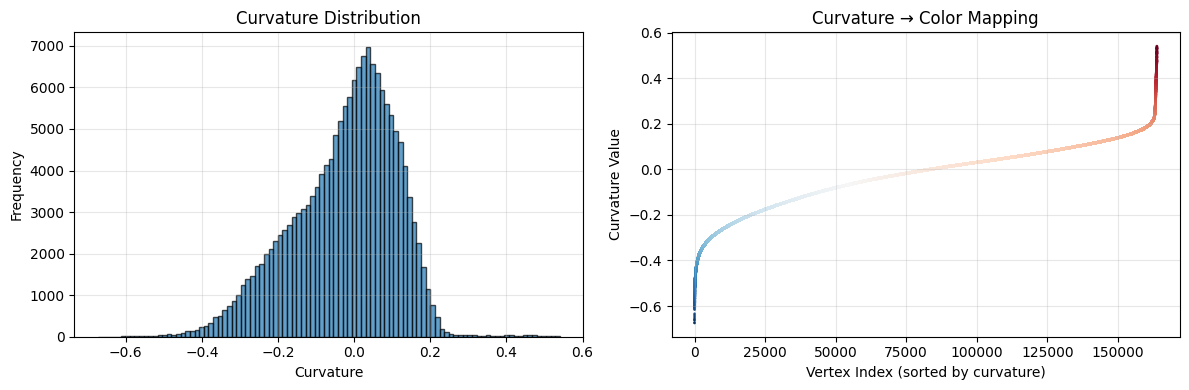

In [5]:
def create_curvature_colors(curvature_values, colormap='RdBu_r'):
    """Convert curvature values to RGB vertex colors"""
    import matplotlib.cm as cm
    import matplotlib.colors as colors
    
    # Normalize curvature to [0, 1] range
    curv_norm = colors.Normalize(vmin=curvature_values.min(), vmax=curvature_values.max())
    
    # Apply colormap
    cmap = cm.get_cmap(colormap)
    colors_rgba = cmap(curv_norm(curvature_values))
    
    # Convert to RGB (0-255) and drop alpha
    colors_rgb = (colors_rgba[:, :3] * 255).astype(np.uint8)
    
    return colors_rgb

# Test color mapping
test_colors = create_curvature_colors(curvature)
print(f"Color mapping: {test_colors.shape} RGB values")
print(f"Color range: R[{test_colors[:,0].min()}-{test_colors[:,0].max()}], G[{test_colors[:,1].min()}-{test_colors[:,1].max()}], B[{test_colors[:,2].min()}-{test_colors[:,2].max()}]")

# Visualize curvature distribution and colors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Curvature histogram
ax1.hist(curvature, bins=100, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Curvature')
ax1.set_ylabel('Frequency')
ax1.set_title('Curvature Distribution')
ax1.grid(True, alpha=0.3)

# Color mapping visualization
sorted_indices = np.argsort(curvature)
ax2.scatter(range(len(curvature)), curvature[sorted_indices], 
           c=test_colors[sorted_indices]/255.0, s=1, alpha=0.8)
ax2.set_xlabel('Vertex Index (sorted by curvature)')
ax2.set_ylabel('Curvature Value')
ax2.set_title('Curvature → Color Mapping')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 4: Mesh decimation and LOD generation

In [6]:
def decimate_mesh_with_colors(vertices, faces, vertex_colors, target_vertices):
    """Decimate mesh while preserving vertex colors through interpolation"""
    
    if target_vertices >= len(vertices):
        # No decimation needed
        return vertices, faces, vertex_colors
    
    print(f"  Decimating {len(vertices):,} → {target_vertices:,} vertices...")
    
    # Create PyMeshLab mesh set
    ms = pymeshlab.MeshSet()
    
    # Add original mesh (PyMeshLab expects vertex colors as float [0,1])
    vertex_colors_float = vertex_colors.astype(np.float64) / 255.0
    
    mesh = pymeshlab.Mesh(
        vertex_matrix=vertices.astype(np.float64),
        face_matrix=faces.astype(np.int32),
        v_color_matrix=vertex_colors_float
    )
    ms.add_mesh(mesh)
    
    # Calculate decimation ratio
    decimation_ratio = target_vertices / len(vertices)
    
    # Apply quadric edge collapse decimation
    ms.apply_filter('meshing_decimation_quadric_edge_collapse', 
                   targetfacenum=int(len(faces) * decimation_ratio),
                   preservenormal=True,
                   preservecolor=True,
                   qualitythr=0.3,
                   optimalplacement=True)
    
    # Get decimated mesh
    decimated_mesh = ms.current_mesh()
    
    new_vertices = decimated_mesh.vertex_matrix().astype(np.float32)
    new_faces = decimated_mesh.face_matrix().astype(np.int32)
    new_colors = (decimated_mesh.vertex_color_matrix() * 255).astype(np.uint8)
    
    print(f"  Result: {len(new_vertices):,} vertices, {len(new_faces):,} faces")
    
    return new_vertices, new_faces, new_colors

# Test decimation on one level
print("Testing mesh decimation...")
original_colors = create_curvature_colors(curvature)
test_verts, test_faces, test_colors = decimate_mesh_with_colors(
    vertices, faces, original_colors, 10000
)
print(f"Test successful: {len(test_verts):,} vertices with {len(test_colors):,} colors")

Testing mesh decimation...
  Decimating 163,842 → 10,000 vertices...


C:\Users\diell\AppData\Local\Temp\ipykernel_20236\347821808.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. pymeshlab.pmeshlab.Mesh(vertex_matrix: numpy.ndarray[numpy.float64[m, 3]] = array([], shape=(0, 3), dtype=float64), face_matrix: numpy.ndarray[numpy.int32[m, 3]] = array([], shape=(0, 3), dtype=int32), edge_matrix: numpy.ndarray[numpy.int32[m, 2]] = array([], shape=(0, 2), dtype=int32), v_normals_matrix: numpy.ndarray[numpy.float64[m, 3]] = array([], shape=(0, 3), dtype=float64), f_normals_matrix: numpy.ndarray[numpy.float64[m, 3]] = array([], shape=(0, 3), dtype=float64), v_scalar_array: numpy.ndarray[numpy.float64[m, 1]] = array([], dtype=float64), f_scalar_array: numpy.ndarray[numpy.float64[m, 1]] = array([], dtype=float64), v_color_matrix: numpy.ndarray[numpy.float64[m, 4]] = array([], shape=(0, 4), dtype=float64), f_color_matrix: numpy.ndarray[numpy.float64[m, 4]] = array([], shape=(0, 4), dtype=float64), v_tex_coords_matrix: numpy.ndarray[numpy.float64[m, 2]] = array([], 

## Step 5: Generate all LOD levels

In [ ]:
def create_glb_with_colors(vertices, faces, vertex_colors, output_path):
    """Create GLB file with vertex colors"""
    
    # Create trimesh object
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    
    # Add vertex colors
    mesh.visual.vertex_colors = vertex_colors
    
    # Ensure proper normals
    mesh.vertex_normals  # This computes normals if they don't exist
    
    # Export to GLB
    mesh.export(output_path)
    
    return output_path

# Generate all LOD levels
print("Generating LOD levels...")

lod_meshes = []
original_colors = create_curvature_colors(curvature)

for lod in lod_levels:
    level = lod["level"]
    target = lod["target_vertices"]
    
    print(f"\nGenerating LOD {level} ({lod['description']})...")
    
    # Create LOD directory
    lod_dir = output_dir / f"lod_{level}"
    lod_dir.mkdir(exist_ok=True)
    
    # Decimate mesh
    lod_vertices, lod_faces, lod_colors = decimate_mesh_with_colors(
        vertices, faces, original_colors, target
    )
    
    # Create GLB file
    glb_path = lod_dir / f"sphere_lod{level}.glb"
    create_glb_with_colors(lod_vertices, lod_faces, lod_colors, glb_path)
    
    # Store mesh info for tileset.json
    mesh_info = {
        "level": level,
        "vertices": len(lod_vertices),
        "faces": len(lod_faces),
        "path": str(glb_path.relative_to(output_dir)),
        "geometric_error": geometric_errors[level],
        "file_size": glb_path.stat().st_size
    }
    lod_meshes.append(mesh_info)
    
    print(f"  Created: {glb_path.name} ({mesh_info['file_size']/1024/1024:.1f} MB)")

print("\nLOD generation complete!")
for mesh in lod_meshes:
    print(f"  LOD {mesh['level']}: {mesh['vertices']:,} vertices → {mesh['file_size']/1024/1024:.1f} MB")

## Step 6: Calculate bounding volumes and spatial hierarchy

In [ ]:
def calculate_bounding_sphere(vertices):
    """Calculate bounding sphere for vertices"""
    center = vertices.mean(axis=0)
    radius = np.linalg.norm(vertices - center, axis=1).max()
    return center.tolist(), float(radius)

def calculate_oriented_bounding_box(vertices):
    """Calculate oriented bounding box"""
    # For a sphere, we can use axis-aligned bounding box
    min_coords = vertices.min(axis=0)
    max_coords = vertices.max(axis=0)
    center = (min_coords + max_coords) / 2
    half_axes = (max_coords - min_coords) / 2
    
    # Return as 3D Tiles format: [center_x, center_y, center_z, x_axis, y_axis, z_axis]
    # For axis-aligned box, axes are [half_x, 0, 0, 0, half_y, 0, 0, 0, half_z]
    return [center[0], center[1], center[2],
            half_axes[0], 0, 0,
            0, half_axes[1], 0,
            0, 0, half_axes[2]]

# Calculate bounding volumes for the original sphere
sphere_center, sphere_radius = calculate_bounding_sphere(vertices)
oriented_bbox = calculate_oriented_bounding_box(vertices)

print(f"Bounding sphere: center={sphere_center}, radius={sphere_radius:.2f}")
print(f"Oriented bounding box: {[f'{x:.2f}' for x in oriented_bbox]}")

## Step 7: Create 3D Tiles tileset.json

In [ ]:
def create_tileset_json(lod_meshes, sphere_center, sphere_radius, oriented_bbox):
    """Create 3D Tiles tileset.json specification"""
    
    # Create hierarchical tile structure
    # LOD 0 (highest detail) is leaf, others are parents
    tiles = []
    
    # Start with lowest detail (LOD 3) as root
    for i, mesh in enumerate(reversed(lod_meshes)):  # Start from lowest detail
        level = mesh["level"]
        is_root = (level == max(m["level"] for m in lod_meshes))
        
        tile = {
            "boundingVolume": {
                "box": oriented_bbox
            },
            "geometricError": mesh["geometric_error"],
            "content": {
                "uri": mesh["path"]
            }
        }
        
        # Add children (higher detail levels)
        if level > 0:
            # This tile has a child with higher detail
            child_mesh = next(m for m in lod_meshes if m["level"] == level - 1)
            tile["children"] = [{
                "boundingVolume": {
                    "box": oriented_bbox
                },
                "geometricError": child_mesh["geometric_error"],
                "content": {
                    "uri": child_mesh["path"]
                }
            }]
            
            # Recursively add children for remaining levels
            current_child = tile["children"][0]
            for next_level in range(level - 2, -1, -1):
                next_mesh = next(m for m in lod_meshes if m["level"] == next_level)
                current_child["children"] = [{
                    "boundingVolume": {
                        "box": oriented_bbox
                    },
                    "geometricError": next_mesh["geometric_error"],
                    "content": {
                        "uri": next_mesh["path"]
                    }
                }]
                current_child = current_child["children"][0]
        
        if is_root:
            tiles.append(tile)
            break
    
    # Create the complete tileset
    tileset = {
        "asset": {
            "version": "1.0",
            "generator": "FreeSurfer Sphere LOD Generator",
            "gltfUpAxis": "Y"
        },
        "properties": {
            "surface_type": "sphere",
            "data_overlay": "curvature",
            "hemisphere": "left",
            "vertex_count_full": lod_meshes[0]["vertices"],
            "lod_levels": len(lod_meshes)
        },
        "geometricError": max(mesh["geometric_error"] for mesh in lod_meshes),
        "root": tiles[0]
    }
    
    return tileset

# Create tileset.json
print("Creating tileset.json...")
tileset = create_tileset_json(lod_meshes, sphere_center, sphere_radius, oriented_bbox)

# Save tileset.json
tileset_path = output_dir / "tileset.json"
with open(tileset_path, 'w') as f:
    json.dump(tileset, f, indent=2)

print(f"Created: {tileset_path}")
print(f"Tileset contains {len(lod_meshes)} LOD levels")
print(f"Root geometric error: {tileset['geometricError']}")

## Step 8: Create three.js example HTML file

In [ ]:
# Create a three.js example HTML file
html_content = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>FreeSurfer Sphere - 3D Tiles LOD</title>
    <style>
        body {
            margin: 0;
            padding: 0;
            background: #000;
            font-family: Arial, sans-serif;
            overflow: hidden;
        }
        
        #container {
            width: 100vw;
            height: 100vh;
        }
        
        #info {
            position: absolute;
            top: 10px;
            left: 10px;
            color: white;
            background: rgba(0, 0, 0, 0.7);
            padding: 10px;
            border-radius: 5px;
            z-index: 100;
        }
        
        #stats {
            position: absolute;
            top: 10px;
            right: 10px;
            color: white;
            background: rgba(0, 0, 0, 0.7);
            padding: 10px;
            border-radius: 5px;
            z-index: 100;
            font-family: monospace;
        }
    </style>
</head>
<body>
    <div id="container"></div>
    <div id="info">
        <h3>FreeSurfer Sphere - Curvature LOD</h3>
        <p>Mouse: Rotate | Wheel: Zoom | Right-click: Pan</p>
        <p>LOD levels automatically switch based on distance</p>
    </div>
    <div id="stats">
        <div>LOD Level: <span id="current-lod">-</span></div>
        <div>Vertices: <span id="vertex-count">-</span></div>
        <div>Distance: <span id="camera-distance">-</span></div>
    </div>

    <!-- Include three.js and 3d-tiles-renderer -->
    <script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/3d-tiles-renderer@latest/build/index.umd.js"></script>
    
    <script>
        // Initialize Three.js scene
        const scene = new THREE.Scene();
        const camera = new THREE.PerspectiveCamera(75, window.innerWidth / window.innerHeight, 0.1, 1000);
        const renderer = new THREE.WebGLRenderer({ antialias: true });
        
        renderer.setSize(window.innerWidth, window.innerHeight);
        renderer.setClearColor(0x000000);
        document.getElementById('container').appendChild(renderer.domElement);
        
        // Add lighting
        const ambientLight = new THREE.AmbientLight(0x404040, 0.6);
        scene.add(ambientLight);
        
        const directionalLight = new THREE.DirectionalLight(0xffffff, 0.8);
        directionalLight.position.set(1, 1, 1).normalize();
        scene.add(directionalLight);
        
        // Add orbit controls
        const controls = new THREE.OrbitControls(camera, renderer.domElement);
        controls.enableDamping = true;
        controls.dampingFactor = 0.05;
        
        // Position camera
        camera.position.set(200, 100, 200);
        controls.target.set(0, 0, 0);
        
        // Initialize 3D Tiles
        const tilesRenderer = new TilesRenderer('./tileset.json');
        tilesRenderer.setCamera(camera);
        tilesRenderer.setResolutionFromRenderer(camera, renderer);
        scene.add(tilesRenderer.group);
        
        // Update stats
        function updateStats() {
            const distance = camera.position.distanceTo(controls.target);
            document.getElementById('camera-distance').textContent = distance.toFixed(1);
            
            // Estimate current LOD based on distance
            let currentLOD = 0;
            if (distance > 300) currentLOD = 3;
            else if (distance > 200) currentLOD = 2;
            else if (distance > 150) currentLOD = 1;
            
            document.getElementById('current-lod').textContent = currentLOD;
            
            // Estimate vertex count
            const vertexCounts = [163842, 40000, 10000, 2500];
            document.getElementById('vertex-count').textContent = vertexCounts[currentLOD].toLocaleString();
        }
        
        // Animation loop
        function animate() {
            requestAnimationFrame(animate);
            
            controls.update();
            
            // Update tiles
            tilesRenderer.setCamera(camera);
            tilesRenderer.setResolutionFromRenderer(camera, renderer);
            tilesRenderer.update();
            
            updateStats();
            
            renderer.render(scene, camera);
        }
        
        // Handle window resize
        window.addEventListener('resize', () => {
            camera.aspect = window.innerWidth / window.innerHeight;
            camera.updateProjectionMatrix();
            renderer.setSize(window.innerWidth, window.innerHeight);
            tilesRenderer.setResolutionFromRenderer(camera, renderer);
        });
        
        // Start animation
        animate();
        
        console.log('FreeSurfer Sphere 3D Tiles LOD loaded successfully!');
    </script>
</body>
</html>'''

# Save HTML file
html_path = output_dir / "index.html"
with open(html_path, 'w') as f:
    f.write(html_content)

print(f"Created three.js example: {html_path}")

## Step 9: Generate summary and usage instructions

In [ ]:
# Create README file
readme_content = f'''# FreeSurfer Sphere - 3D Tiles with Level of Detail (LOD)

This directory contains a multiresolution brain sphere dataset optimized for three.js visualization using 3D Tiles with automatic Level of Detail switching.

## Generated Files

### Core 3D Tiles Structure
- `tileset.json` - Main 3D Tiles specification file
- `lod_0/sphere_lod0.glb` - Highest detail ({lod_meshes[0]['vertices']:,} vertices)
- `lod_1/sphere_lod1.glb` - High detail (~{lod_meshes[1]['vertices']:,} vertices)
- `lod_2/sphere_lod2.glb` - Medium detail (~{lod_meshes[2]['vertices']:,} vertices)
- `lod_3/sphere_lod3.glb` - Low detail (~{lod_meshes[3]['vertices']:,} vertices)

### Example Files
- `index.html` - Complete three.js example with 3d-tiles-renderer
- `README.md` - This file

## Usage

### Method 1: Local HTTP Server
```bash
# Navigate to this directory
cd sphere_3dtiles

# Start a local HTTP server (Python 3)
python -m http.server 8000

# Or use Node.js http-server
npx http-server -p 8000

# Open in browser
# http://localhost:8000
```

### Method 2: Integration in Existing Project
```javascript
import {{ TilesRenderer }} from '3d-tiles-renderer';
import * as THREE from 'three';

// Initialize Three.js scene
const scene = new THREE.Scene();
const camera = new THREE.PerspectiveCamera(75, window.innerWidth / window.innerHeight, 0.1, 1000);
const renderer = new THREE.WebGLRenderer();

// Load 3D Tiles
const tilesRenderer = new TilesRenderer('./path/to/tileset.json');
tilesRenderer.setCamera(camera);
tilesRenderer.setResolutionFromRenderer(camera, renderer);
scene.add(tilesRenderer.group);

// Animation loop
function animate() {{
    tilesRenderer.setCamera(camera);
    tilesRenderer.setResolutionFromRenderer(camera, renderer);
    tilesRenderer.update();
    
    renderer.render(scene, camera);
    requestAnimationFrame(animate);
}}
```

## LOD Behavior

The 3D Tiles renderer automatically switches between detail levels based on:
- **Camera distance** - Closer views use higher detail
- **Screen space error** - Maintains visual quality
- **Performance** - Automatically balances quality vs. frame rate

### LOD Switching Distances (approximate)
- **LOD 0** ({lod_meshes[0]['vertices']:,} vertices): Distance < 150 units
- **LOD 1** ({lod_meshes[1]['vertices']:,} vertices): Distance 150-200 units  
- **LOD 2** ({lod_meshes[2]['vertices']:,} vertices): Distance 200-300 units
- **LOD 3** ({lod_meshes[3]['vertices']:,} vertices): Distance > 300 units

## Data Specifications

### Surface Data
- **Source**: FreeSurfer fsaverage left hemisphere sphere
- **Overlay**: Curvature data (sulci/gyri visualization)
- **Colormap**: RdBu_r (blue=negative curvature, red=positive curvature)
- **Coordinate System**: Centered at origin, ~100 unit radius

### File Sizes
```
Total dataset: {sum(m['file_size'] for m in lod_meshes)/1024/1024:.1f} MB
''' + '\n'.join([f"  LOD {m['level']}: {m['file_size']/1024/1024:.1f} MB ({m['vertices']:,} vertices)" for m in lod_meshes]) + f'''
```

## Technical Details

### 3D Tiles Specification
- **Version**: 1.0
- **Bounding Volume**: Oriented bounding box
- **Geometric Error**: Tuned for brain visualization
- **Content Format**: GLB (Binary glTF)

### Mesh Processing
- **Decimation**: Quadric edge collapse with color preservation
- **Normal Computation**: Automatic vertex normal generation
- **Color Encoding**: RGB vertex colors (8-bit per channel)
- **Optimization**: Compressed with deflate, optimized chunk sizes

## Dependencies

For web visualization:
- [three.js](https://threejs.org/) (r128+)
- [3d-tiles-renderer](https://github.com/NASA-AMMOS/3DTilesRendererJS)

## Browser Compatibility

- ✅ Chrome 80+
- ✅ Firefox 75+
- ✅ Safari 14+
- ✅ Edge 80+

WebGL 2.0 recommended for optimal performance.
'''

# Save README
readme_path = output_dir / "README.md"
with open(readme_path, 'w') as f:
    f.write(readme_content)

print(f"Created documentation: {readme_path}")

# Final summary
print("\n" + "="*60)
print("🎉 3D Tiles LOD Generation Complete!")
print("="*60)
print(f"Output directory: {output_dir}")
print(f"Total files: {len(list(output_dir.rglob('*')))}")
print(f"Dataset size: {sum(m['file_size'] for m in lod_meshes)/1024/1024:.1f} MB")

print("\nLOD Levels Generated:")
for mesh in lod_meshes:
    print(f"  LOD {mesh['level']}: {mesh['vertices']:,} vertices ({mesh['file_size']/1024/1024:.1f} MB)")

print("\nNext Steps:")
print("1. Start local HTTP server in the output directory")
print("2. Open index.html in your browser")
print("3. Test LOD switching by zooming in/out")
print("4. Integrate tileset.json into your three.js application")

print("\n📁 Directory structure:")
for item in sorted(output_dir.rglob('*')):
    if item.is_file():
        rel_path = item.relative_to(output_dir)
        size = item.stat().st_size
        if size > 1024*1024:
            size_str = f"{size/1024/1024:.1f} MB"
        elif size > 1024:
            size_str = f"{size/1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"  {rel_path} ({size_str})")